# Phân tích Trực quan Phân bố và Resampling
Notebook này phân tích sự thay đổi của các đặc trưng `Time` và `Amount` trước và sau khi chuẩn hóa, và so sánh phân bố của dữ liệu sau khi cân bằng sử dụng **SMOTE** và **ADASYN**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, ADASYN

import warnings
warnings.filterwarnings('ignore')

# Tải dữ liệu
df = pd.read_csv('creditcard_processed.csv')
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df = df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Lưu trữ bản sao chưa scale
X_train_unscaled = X_train.copy()

preprocessor = ColumnTransformer([
    ('scaler', RobustScaler(), ['Time', 'Amount'])
], remainder='passthrough')

X_train_scaled = preprocessor.fit_transform(X_train)

X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_train_scaled_df.columns = ['Time_Scaled', 'Amount_Scaled'] + [c for c in X_train.columns if c not in ['Time', 'Amount']]


## 1. Phân bố Time và Amount Trước và Sau Chuẩn Hóa

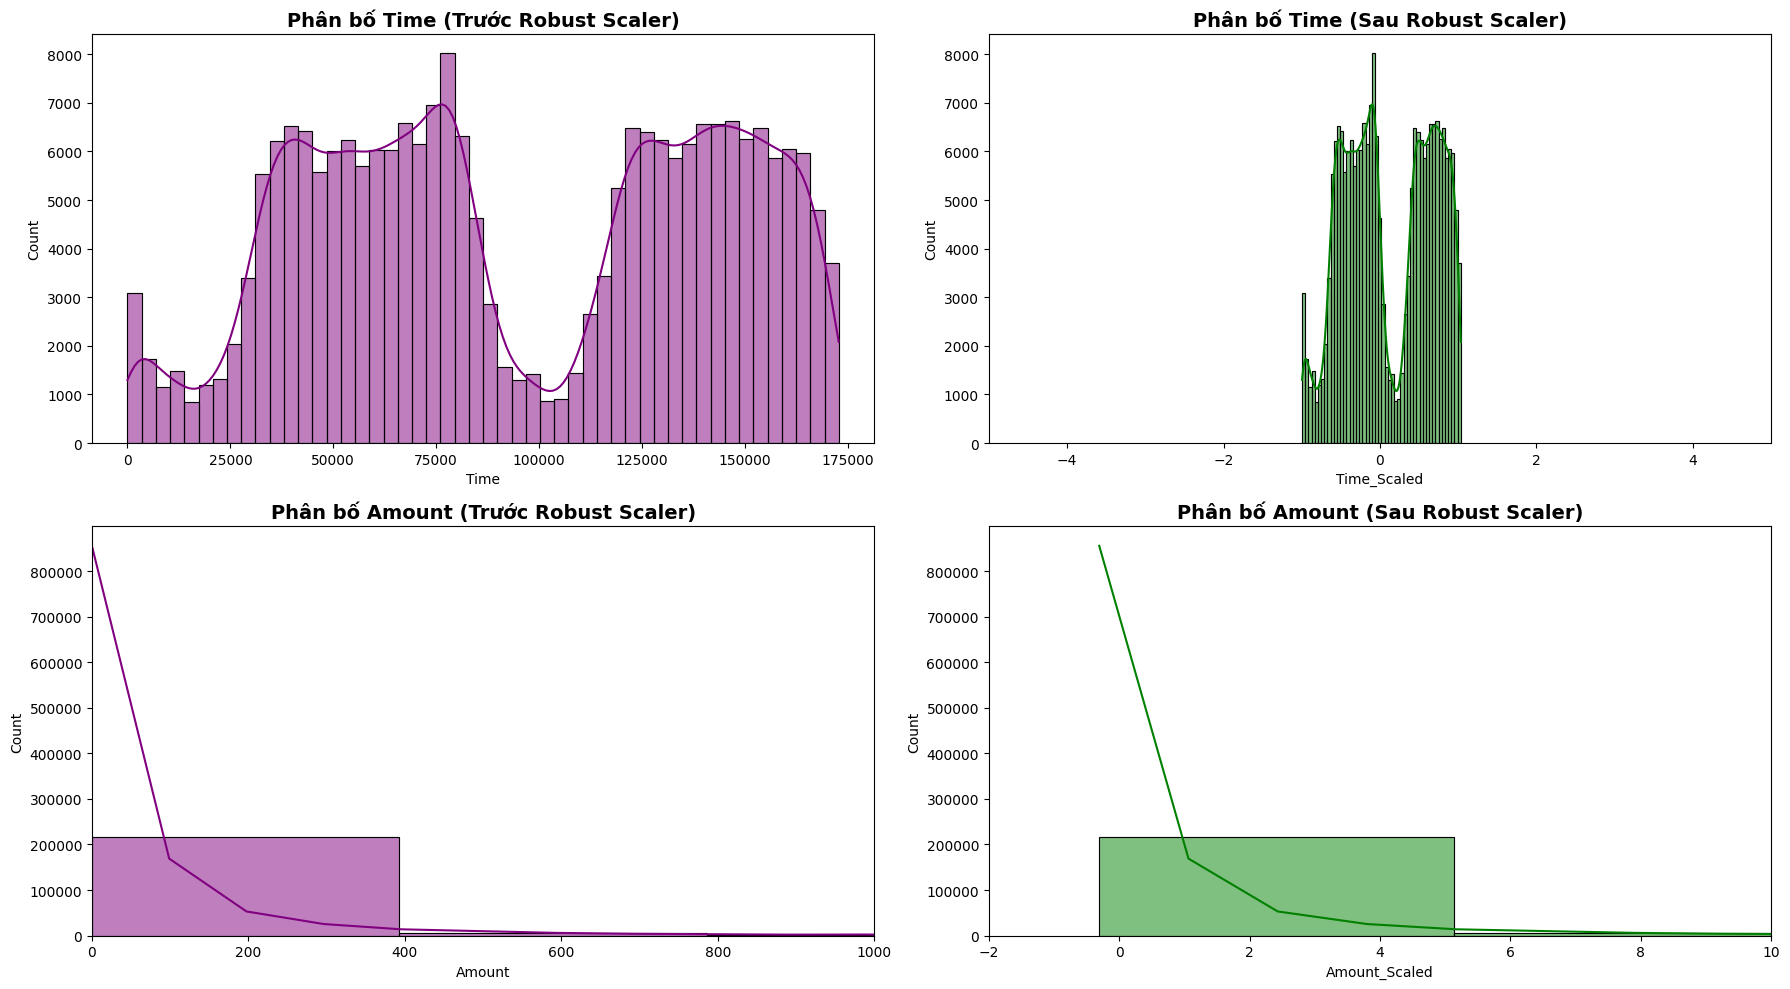

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Time - Trước chuẩn hóa
sns.histplot(X_train_unscaled['Time'], kde=True, color='purple', ax=axes[0, 0], bins=50)
axes[0, 0].set_title('Phân bố Time (Trước Robust Scaler)', fontsize=14, fontweight='bold')

# Time - Sau chuẩn hóa
sns.histplot(X_train_scaled_df['Time_Scaled'], kde=True, color='green', ax=axes[0, 1], bins=50)
axes[0, 1].set_title('Phân bố Time (Sau Robust Scaler)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim(-5, 5)

# Amount - Trước chuẩn hóa
sns.histplot(X_train_unscaled['Amount'], kde=True, color='purple', ax=axes[1, 0], bins=50)
axes[1, 0].set_title('Phân bố Amount (Trước Robust Scaler)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim(0, 1000)

# Amount - Sau chuẩn hóa
sns.histplot(X_train_scaled_df['Amount_Scaled'], kde=True, color='green', ax=axes[1, 1], bins=50)
axes[1, 1].set_title('Phân bố Amount (Sau Robust Scaler)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim(-2, 10)

plt.tight_layout()
plt.show()


## 2. Phân bố không gian dữ liệu sau Resampling (Original, SMOTE, ADASYN)
Chúng ta sẽ so sánh 3 trạng thái phân bố:
1. **Dữ liệu gốc** (Original Data).
2. **Dữ liệu sau SMOTE** (Các điểm nhân tạo sinh ra nối giữa các điểm gốc).
3. **Dữ liệu sau ADASYN** (Các điểm nhân tạo co cụm tại các vị trí gian lận khó phân loại).

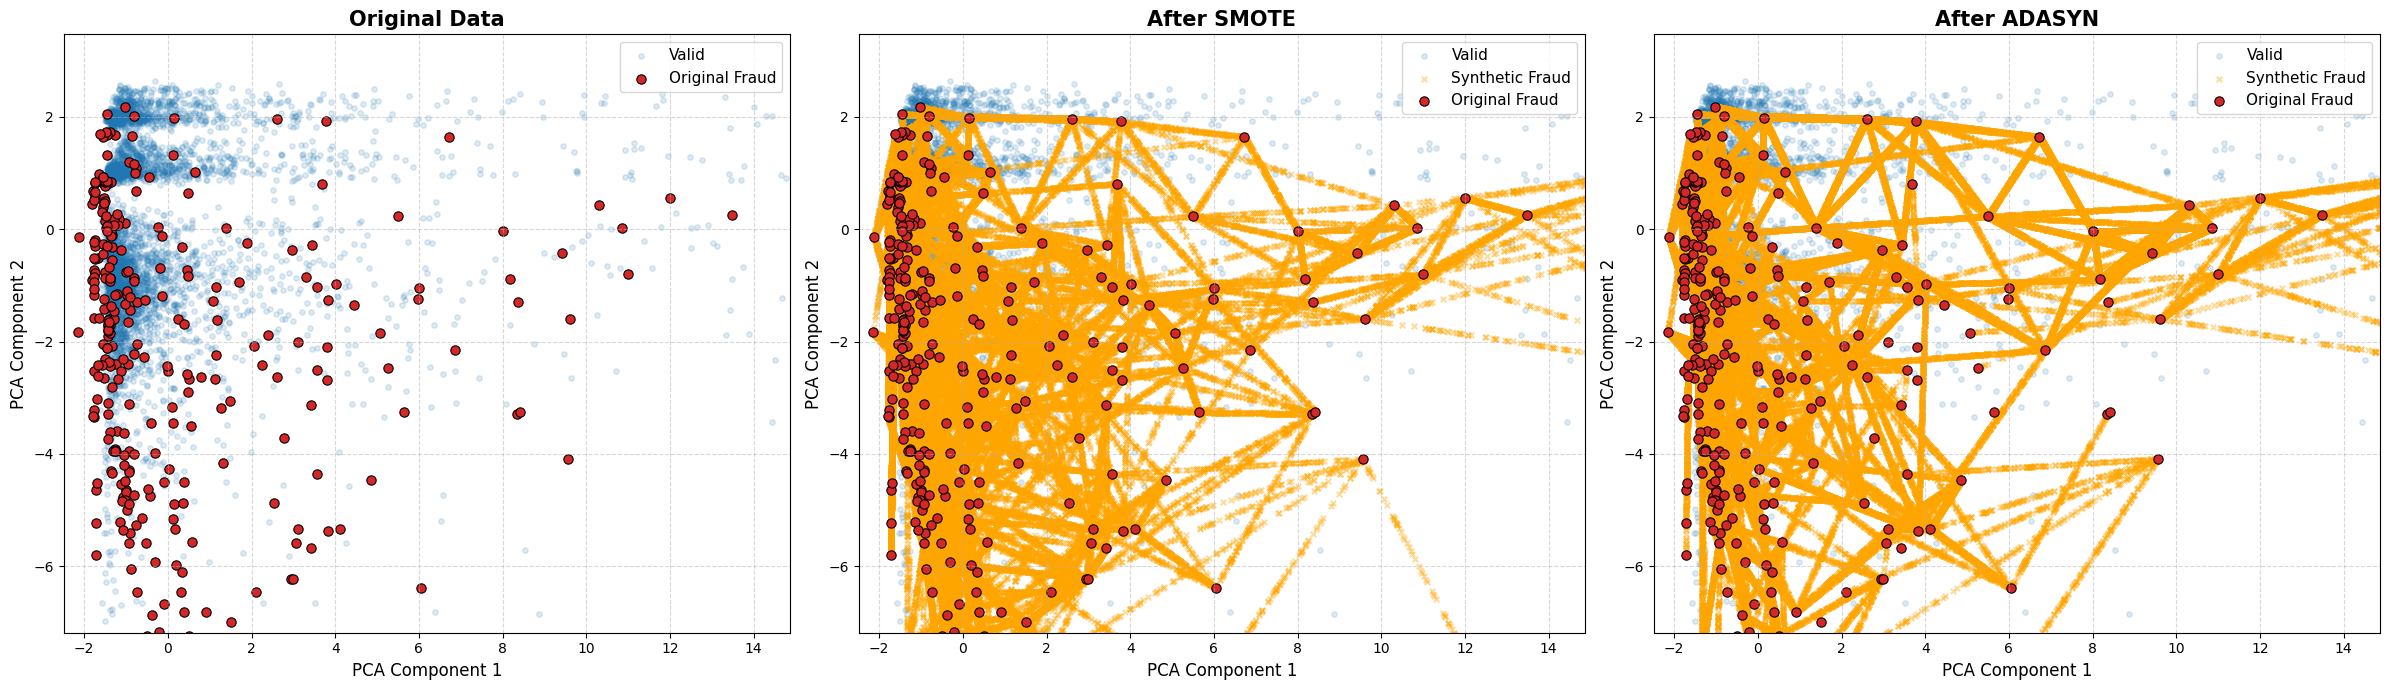

In [3]:
smote = SMOTE(random_state=42)
adasyn = ADASYN(n_neighbors=5, random_state=42)

X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
X_smote_pca = pca.transform(X_smote)
X_adasyn_pca = pca.transform(X_adasyn)

x_min, x_max = np.percentile(X_pca[:, 0], 1) - 1, np.percentile(X_pca[:, 0], 99) + 1
y_min, y_max = np.percentile(X_pca[:, 1], 1) - 1, np.percentile(X_pca[:, 1], 99) + 1

def plot_resampling_diff(X_orig, y_orig, X_resampled, title, ax):
    y_orig = np.array(y_orig)
    valid_idx = np.where(y_orig == 0)[0]
    fraud_idx = np.where(y_orig == 1)[0]
    
    np.random.seed(42)
    valid_sampled_idx = np.random.choice(valid_idx, size=min(5000, len(valid_idx)), replace=False)
    
    ax.scatter(X_orig[valid_sampled_idx, 0], X_orig[valid_sampled_idx, 1], 
               c='#1f77b4', alpha=0.15, label='Valid', s=15)
               
    if X_resampled is not None:
        n_orig = len(X_orig)
        X_synthetic = X_resampled[n_orig:]
        if len(X_synthetic) > 0:
            ax.scatter(X_synthetic[:, 0], X_synthetic[:, 1], 
                       c='orange', alpha=0.4, label='Synthetic Fraud', s=15, marker='x')
                       
    ax.scatter(X_orig[fraud_idx, 0], X_orig[fraud_idx, 1], 
               c='#d62728', alpha=1.0, label='Original Fraud', s=45, edgecolor='black', linewidth=0.8)
               
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('PCA Component 1', fontsize=12)
    ax.set_ylabel('PCA Component 2', fontsize=12)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig3, axes3 = plt.subplots(1, 3, figsize=(24, 7))

plot_resampling_diff(X_pca, y_train, None, 'Original Data', axes3[0])
plot_resampling_diff(X_pca, y_train, X_smote_pca, 'After SMOTE', axes3[1])
plot_resampling_diff(X_pca, y_train, X_adasyn_pca, 'After ADASYN', axes3[2])

plt.tight_layout()
plt.show()
